# Case-Based Reasoning (CBR) — Sistem Analisis Putusan Pengadilan
## Domain: Pidana Khusus Narkotika & Psikotropika
**Mata Kuliah**: Penalaran Komputer — SubCPMK-3  
**Universitas Muhammadiyah Malang — Fakultas Teknik Informatika**

---
Notebook ini mengintegrasikan seluruh siklus CBR:
1. Tahap 1 — Membangun Case Base
2. Tahap 2 — Case Representation
3. Tahap 3 — Case Retrieval (TF-IDF + SVM)
4. Tahap 4 — Case Solution Reuse
5. Tahap 5 — Model Evaluation

## Setup & Import

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

print('✓ Imports OK')
print(f'  Working dir: {os.getcwd()}')

✓ Imports OK
  Working dir: e:\ragil\semester 6\Penalaran Komputer\cbr_narkotika\cbr_narkotika\notebooks


---
## Tahap 1: Membangun Case Base

In [2]:
# Generate synthetic data (replaces scraping from MA RI)
%run ../generate_data.py

  [+] case_001.txt  |  101/Pid.Sus/2023/PN.Bdg  |  Ahmad Fauzi
  [+] case_002.txt  |  102/Pid.Sus/2022/PN.Mdn  |  Budi Santoso
  [+] case_003.txt  |  103/Pid.Sus/2020/PN.Mdn  |  Cipto Haryono
  [+] case_004.txt  |  104/Pid.Sus/2022/PN.Mks  |  Dedi Kurniawan
  [+] case_005.txt  |  105/Pid.Sus/2022/PN.Sby  |  Eko Prasetyo
  [+] case_006.txt  |  106/Pid.Sus/2023/PN.Mdn  |  Fahri Maulana
  [+] case_007.txt  |  107/Pid.Sus/2023/PN.Mdn  |  Gunawan Hidayat
  [+] case_008.txt  |  108/Pid.Sus/2022/PN.Mks  |  Hendra Wijaya
  [+] case_009.txt  |  109/Pid.Sus/2024/PN.Jkt.Sel  |  Irwan Saputra
  [+] case_010.txt  |  110/Pid.Sus/2021/PN.Bdg  |  Joko Susilo
  [+] case_011.txt  |  111/Pid.Sus/2022/PN.Jkt.Sel  |  Kurnia Ramadhan
  [+] case_012.txt  |  112/Pid.Sus/2022/PN.Sby  |  Lukman Hakim
  [+] case_013.txt  |  113/Pid.Sus/2022/PN.Bdg  |  Muhamad Rizky
  [+] case_014.txt  |  114/Pid.Sus/2020/PN.Mks  |  Nanang Setiawan
  [+] case_015.txt  |  115/Pid.Sus/2020/PN.Bdg  |  Oki Firmansyah
  [+] case_016.t

In [3]:
# Cleaning & Validation
%run ../01_case_base.py

[Tahap 1] Membangun Case Base  |  2026-06-11 08:24:43.222564
Jumlah file ditemukan: 35
[OK] case_001.txt         | pct= 98.5% | tokens=  521
[OK] case_002.txt         | pct= 98.4% | tokens=  517
[OK] case_003.txt         | pct= 98.4% | tokens=  501
[OK] case_004.txt         | pct= 98.5% | tokens=  518
[OK] case_005.txt         | pct= 98.4% | tokens=  504
[OK] case_006.txt         | pct= 98.4% | tokens=  508
[OK] case_007.txt         | pct= 98.5% | tokens=  518
[OK] case_008.txt         | pct= 98.4% | tokens=  510
[OK] case_009.txt         | pct= 98.5% | tokens=  525
[OK] case_010.txt         | pct= 98.5% | tokens=  518
[OK] case_011.txt         | pct= 98.4% | tokens=  511
[OK] case_012.txt         | pct= 98.4% | tokens=  510
[OK] case_013.txt         | pct= 98.4% | tokens=  514
[OK] case_014.txt         | pct= 98.4% | tokens=  507
[OK] case_015.txt         | pct= 98.4% | tokens=  503
[OK] case_016.txt         | pct= 98.4% | tokens=  514
[OK] case_017.txt         | pct= 98.5% | tokens= 


=== Tahap 1 Selesai: 35/35 dokumen valid ===


In [4]:
# Inspect cleaning log
with open('../logs/cleaning.log') as f:
    lines = f.readlines()
print(''.join(lines[:10]))
print(f'...\nTotal log lines: {len(lines)}')

[Cleaning Log] 2026-06-11 07:54:50.759934
[OK] case_001.txt         | pct=100.0% | tokens=  521
[OK] case_002.txt         | pct=100.0% | tokens=  517
[OK] case_003.txt         | pct=100.0% | tokens=  501
[OK] case_004.txt         | pct=100.0% | tokens=  518
[OK] case_005.txt         | pct=100.0% | tokens=  504
[OK] case_006.txt         | pct=100.0% | tokens=  508
[OK] case_007.txt         | pct=100.0% | tokens=  518
[OK] case_008.txt         | pct=100.0% | tokens=  510
[OK] case_009.txt         | pct=100.0% | tokens=  525

...
Total log lines: 119


In [5]:
# Preview one cleaned document
with open('../data/raw/case_001.txt') as f:
    print(f.read()[:800])

PUTUSAN
Nomor 101/Pid.Sus/2023/PN.Bdg

DEMI KEADILAN BERDASARKAN KETUHANAN YANG MAHA ESA

PENGADILAN NEGERI JAKARTA SELATAN

yang memeriksa dan mengadili perkara pidana khusus Narkotika dan Psikotropika pada 
tingkat pertama, telah menjatuhkan putusan sebagai berikut dalam perkara Terdakwa:

Nama Lengkap : Ahmad Fauzi
Tempat Lahir : Jakarta
Umur/Tanggal Lahir : 50 Tahun
Jenis Kelamin : Laki-laki
Kebangsaan : Indonesia
Agama : Katolik
Pekerjaan : Swasta
Alamat : Jl. Melati No.184, Medan

Terdakwa ditangkap oleh petugas Kepolisian pada tanggal 2 August 2023 di jalan raya 
berdasarkan informasi dari masyarakat setempat.

DAKWAAN:

Bahwa Terdakwa Ahmad Fauzi pada hari Selasa 
tanggal 2 August 2023, bertempat di wilayah hukum Pengadilan Negeri Jakarta Selatan, 
terbukti menjadi perantara jual b


---
## Tahap 2: Case Representation

In [6]:
%run ../02_case_representation.py

  [+] case_001.txt  →  Ahmad Fauzi | sabu-sabu | pidana penjara
  [+] case_002.txt  →  Budi Santoso | ganja | pidana penjara
  [+] case_003.txt  →  Cipto Haryono | heroin | penjara seumur hidup
  [+] case_004.txt  →  Dedi Kurniawan | ganja | pidana penjara
  [+] case_005.txt  →  Eko Prasetyo | kokain | pidana penjara
  [+] case_006.txt  →  Fahri Maulana | kokain | penjara seumur hidup
  [+] case_007.txt  →  Gunawan Hidayat | ganja | penjara seumur hidup
  [+] case_008.txt  →  Hendra Wijaya | heroin | penjara seumur hidup
  [+] case_009.txt  →  Irwan Saputra | sabu-sabu | penjara seumur hidup
  [+] case_010.txt  →  Joko Susilo | sabu-sabu | penjara seumur hidup
  [+] case_011.txt  →  Kurnia Ramadhan | ganja | penjara seumur hidup
  [+] case_012.txt  →  Lukman Hakim | kokain | penjara seumur hidup
  [+] case_013.txt  →  Muhamad Rizky | ganja | pidana penjara
  [+] case_014.txt  →  Nanang Setiawan | ganja | penjara seumur hidup
  [+] case_015.txt  →  Oki Firmansyah | heroin | pidana penja

In [7]:
df = pd.read_csv('../data/processed/cases.csv', encoding='utf-8-sig')
print(f'Shape: {df.shape}')
df[['case_id','no_perkara','tanggal','terdakwa','jenis_narkoba','label_putusan']].head(10)

Shape: (35, 17)


,case_id,no_perkara,tanggal,terdakwa,jenis_narkoba,label_putusan
0,1,101/Pid.Sus/2023/PN.Bdg,2023-08-02,Ahmad Fauzi,sabu-sabu,pidana penjara
1,2,102/Pid.Sus/2022/PN.Mdn,2022-05-15,Budi Santoso,ganja,pidana penjara
2,3,103/Pid.Sus/2020/PN.Mdn,2020-06-12,Cipto Haryono,heroin,penjara seumur hidup
3,4,104/Pid.Sus/2022/PN.Mks,2022-04-01,Dedi Kurniawan,ganja,pidana penjara
4,5,105/Pid.Sus/2022/PN.Sby,2022-05-14,Eko Prasetyo,kokain,pidana penjara
5,6,106/Pid.Sus/2023/PN.Mdn,2023-01-09,Fahri Maulana,kokain,penjara seumur hidup
6,7,107/Pid.Sus/2023/PN.Mdn,2023-10-07,Gunawan Hidayat,ganja,penjara seumur hidup
7,8,108/Pid.Sus/2022/PN.Mks,2022-08-26,Hendra Wijaya,heroin,penjara seumur hidup
8,9,109/Pid.Sus/2024/PN.Jkt.Sel,2024-11-25,Irwan Saputra,sabu-sabu,penjara seumur hidup
9,10,110/Pid.Sus/2021/PN.Bdg,2021-03-21,Joko Susilo,sabu-sabu,penjara seumur hidup


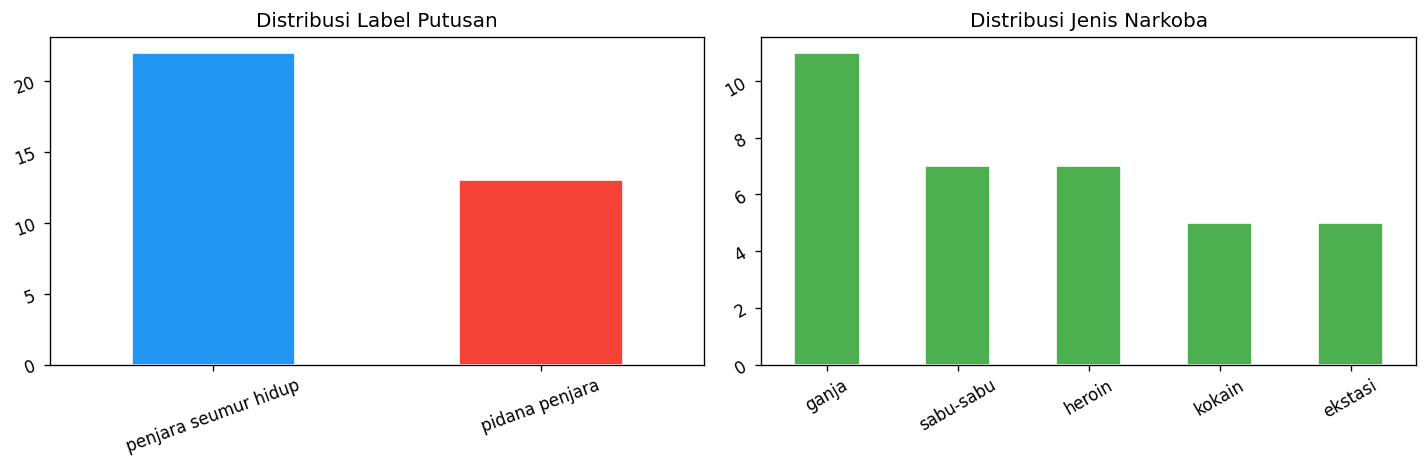

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['label_putusan'].value_counts().plot.bar(ax=axes[0], color=['#2196F3','#F44336'], edgecolor='white')
axes[0].set_title('Distribusi Label Putusan')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=20)

df['jenis_narkoba'].value_counts().plot.bar(ax=axes[1], color='#4CAF50', edgecolor='white')
axes[1].set_title('Distribusi Jenis Narkoba')
axes[1].set_xlabel('')
axes[1].tick_params(rotation=30)

plt.tight_layout()
plt.savefig('../data/eval/distribusi.png', dpi=120)
plt.show()

---
## Tahap 3: Case Retrieval

In [9]:
%run ../03_retrieval.py

[Tahap 3] Case Retrieval  |  TF-IDF + SVM

[1] Data loaded: 35 kasus

[2] Building TF-IDF vectors...
  TF-IDF matrix shape: (35, 854)

[3] Training SVM classifier (70/30 split)...
  SVM  Train Accuracy: 1.0000
  SVM  Test  Accuracy: 0.5455

[4] Model tersimpan → models/

[5] Pengujian Awal — Test Queries:
------------------------------------------------------------
  Q001: terdakwa memiliki sabu-sabu seberat 50 gram tanpa ...
    Top-5 retrieved : [22, 30, 34, 10, 28]
    Similarities    : ['0.330', '0.287', '0.284', '0.283', '0.282']
    Predicted label : penjara seumur hidup (expected: pidana penjara)
    Hit@5           : ✓
  Q002: terdakwa menyimpan ganja seberat 2 kilogram di rum...
    Top-5 retrieved : [23, 25, 26, 2, 7]
    Similarities    : ['0.305', '0.304', '0.266', '0.260', '0.258']
    Predicted label : penjara seumur hidup (expected: penjara seumur hidup)
    Hit@5           : ✓
  Q003: terdakwa menjadi perantara jual beli heroin dianca...
    Top-5 retrieved : [29, 15, 8

In [10]:
import json, pickle, scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity

vectorizer   = pickle.load(open('../models/tfidf_vectorizer.pkl','rb'))
clf          = pickle.load(open('../models/svm_classifier.pkl','rb'))
le           = pickle.load(open('../models/label_encoder.pkl','rb'))
tfidf_matrix = sp.load_npz('../models/tfidf_matrix.npz')
df           = pd.read_csv('../data/processed/cases.csv', encoding='utf-8-sig')

print('Models loaded ✓')
print(f'TF-IDF matrix: {tfidf_matrix.shape}')

Models loaded ✓
TF-IDF matrix: (35, 854)


In [11]:
def retrieve(query, k=5):
    q_vec = vectorizer.transform([query.lower()])
    sims  = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_k = np.argsort(sims)[::-1][:k]
    return [(int(df.iloc[i]['case_id']), round(float(sims[i]),4)) for i in top_k]

# Test live retrieval
query = 'terdakwa memiliki sabu-sabu seberat 50 gram pasal 112'
results = retrieve(query, k=5)
print(f'Query: "{query}"\n')
for cid, sim in results:
    row = df[df['case_id']==cid].iloc[0]
    print(f'  Case {cid:3d}  sim={sim:.4f}  {row["terdakwa"]:20s}  {row["jenis_narkoba"]:12s}  {row["label_putusan"]}')

Query: "terdakwa memiliki sabu-sabu seberat 50 gram pasal 112"

  Case  22  sim=0.3700  Vicky Andrianto       sabu-sabu     penjara seumur hidup
  Case  30  sim=0.2526  Dani Saputra          sabu-sabu     pidana penjara
  Case  34  sim=0.2495  Hadi Wijaya           sabu-sabu     pidana penjara
  Case  10  sim=0.2488  Joko Susilo           sabu-sabu     penjara seumur hidup
  Case  28  sim=0.2484  Bambang Riyanto       sabu-sabu     penjara seumur hidup


---
## Tahap 4: Case Solution Reuse

In [12]:
%run ../04_predict.py

[Tahap 4] Case Solution Reuse

  [NEW-001] terdakwa ditemukan membawa sabu-sabu 3 gram dalam kantong ce...
    Top-5 IDs         : [22, 30, 10, 34, 28]
    Top-5 Labels      : ['penjara seumur hidup', 'pidana penjara', 'penjara seumur hidup', 'pidana penjara', 'penjara seumur hidup']
    Predicted Label   : penjara seumur hidup
    Actual Label      : pidana penjara
    Match             : ✗
    Rep. Amar Putusan : Menjatuhkan pidana kepada Terdakwa dengan pidana penjara seumur hidup dan denda ...

  [NEW-002] tersangka menyimpan 1500 gram heroin dikemas dalam paket di ...
    Top-5 IDs         : [31, 35, 27, 29, 3]
    Top-5 Labels      : ['penjara seumur hidup', 'penjara seumur hidup', 'pidana penjara', 'pidana penjara', 'penjara seumur hidup']
    Predicted Label   : penjara seumur hidup
    Actual Label      : penjara seumur hidup
    Match             : ✓
    Rep. Amar Putusan : Menjatuhkan pidana kepada Terdakwa dengan pidana penjara seumur hidup dan denda ...

  [NEW-003] terdak

In [13]:
pred_df = pd.read_csv('../data/results/predictions.csv', encoding='utf-8-sig')
pred_df[['query_id','predicted_solution','actual_label','match']]

,query_id,predicted_solution,actual_label,match
0,NEW-001,penjara seumur hidup,pidana penjara,False
1,NEW-002,penjara seumur hidup,penjara seumur hidup,True
2,NEW-003,pidana penjara,pidana penjara,True
3,NEW-004,penjara seumur hidup,pidana penjara,False
4,NEW-005,penjara seumur hidup,penjara seumur hidup,True


---
## Tahap 5: Model Evaluation

In [14]:
%run ../05_evaluation.py

[Tahap 5] Model Evaluation

[1] Evaluasi Retrieval (Hit@5)...
query_id  hit_at_k  precision_at_k  recall_at_k  f1_at_k
    Q001         1             0.4       0.6667   0.5000
    Q002         1             0.6       0.6000   0.6000
    Q003         1             0.4       0.6667   0.5000
    Q004         1             0.8       1.0000   0.8889
    Q005         1             1.0       1.0000   1.0000
    Q006         1             1.0       1.0000   1.0000
    Q007         1             1.0       0.7143   0.8333

  Aggregate: {'Hit@5': np.float64(1.0), 'Precision': np.float64(0.7428571428571429), 'Recall': np.float64(0.8068142857142856), 'F1': np.float64(0.7603142857142858)}
  Tersimpan → e:\ragil\semester 6\Penalaran Komputer\cbr_narkotika\cbr_narkotika\data\eval\retrieval_metrics.csv

[2] Evaluasi SVM Classification...
  Accuracy  : 0.8571
  Precision : 0.8561
  Recall    : 0.8571
  F1        : 0.8559
  CV Acc    : 0.6857 ± 0.1666

  Prediction Accuracy: 60.00%
  Tersimpan → e:\ragil

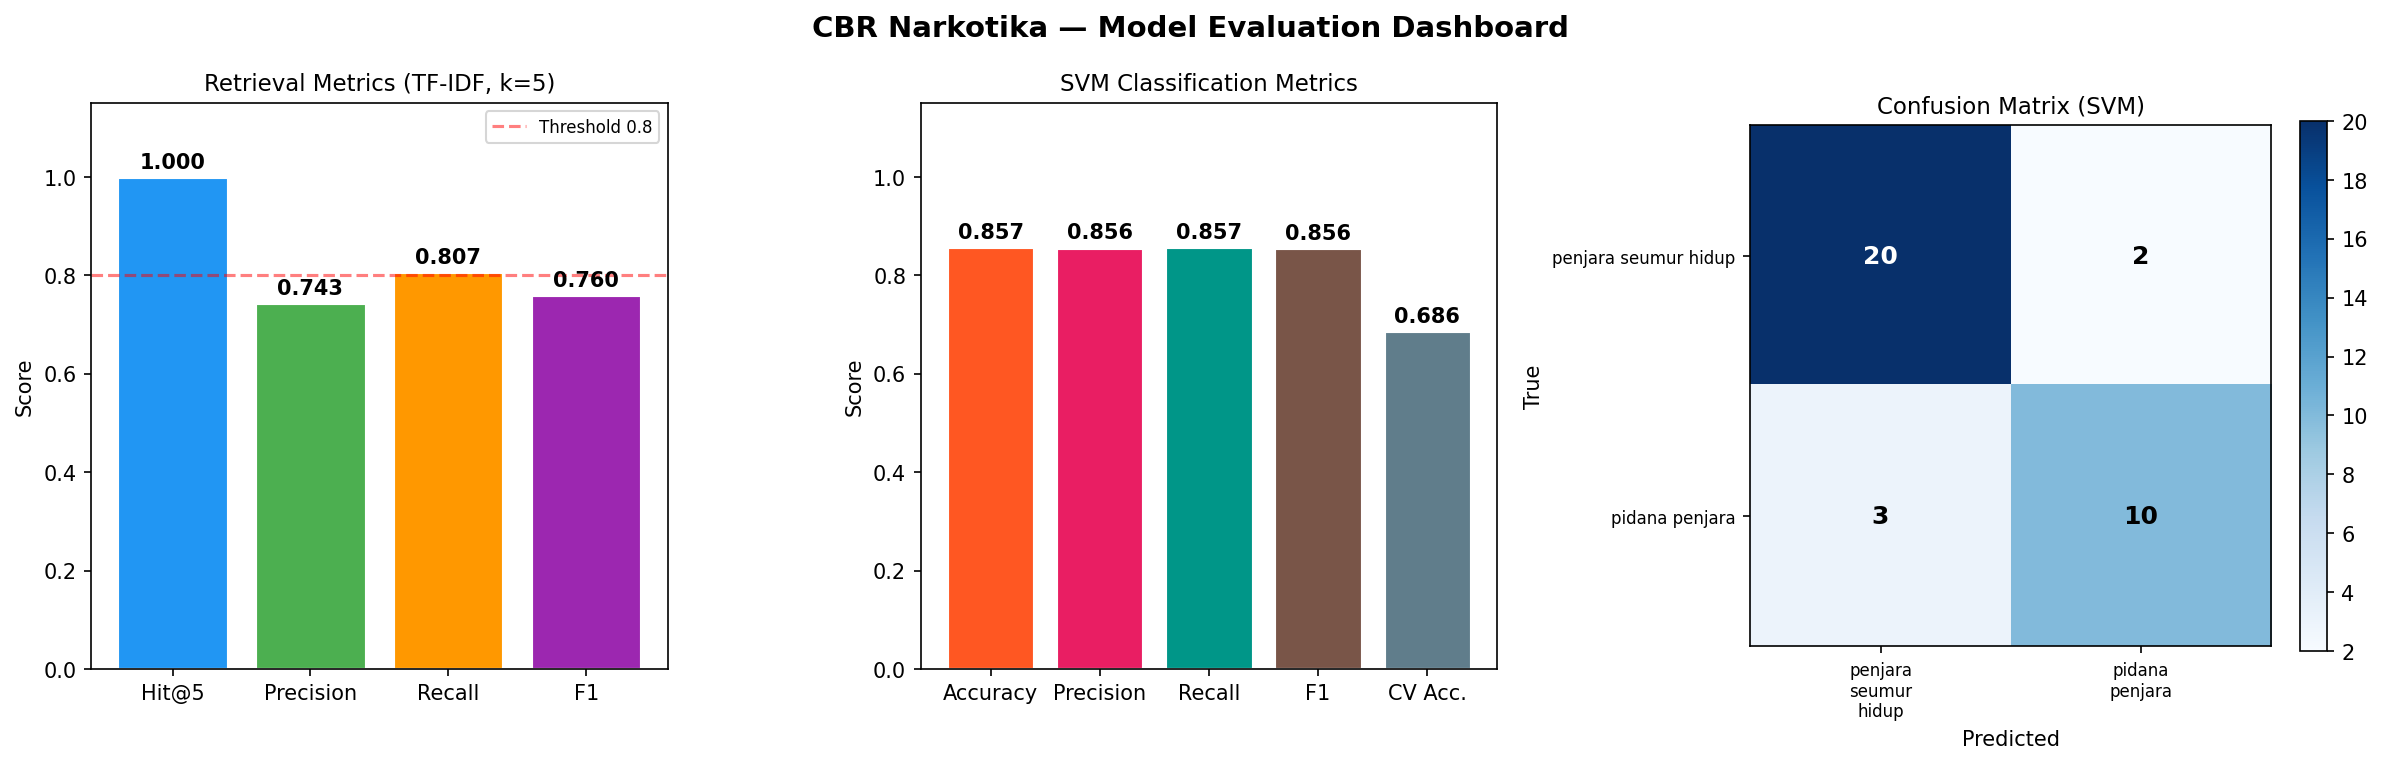

In [15]:
# Show performance chart
from IPython.display import Image
Image('../data/eval/performance_chart.png')

In [16]:
# Print evaluation report
with open('../data/eval/evaluation_report.txt') as f:
    print(f.read())

LAPORAN EVALUASI MODEL CBR
Domain: Pidana Khusus Narkotika & Psikotropika
Metode: TF-IDF + LinearSVC

â”€â”€ RETRIEVAL METRICS (TF-IDF Cosine Similarity, k=5) â”€â”€
  Hit@5       : 1.0000
  Precision   : 0.7429
  Recall      : 0.8068
  F1          : 0.7603

â”€â”€ PER-QUERY RETRIEVAL DETAIL â”€â”€
  Q001: Hit=1  P=0.400  R=0.667  F1=0.500
  Q002: Hit=1  P=0.600  R=0.600  F1=0.600
  Q003: Hit=1  P=0.400  R=0.667  F1=0.500
  Q004: Hit=1  P=0.800  R=1.000  F1=0.889
  Q005: Hit=1  P=1.000  R=1.000  F1=1.000
  Q006: Hit=1  P=1.000  R=1.000  F1=1.000
  Q007: Hit=1  P=1.000  R=0.714  F1=0.833

â”€â”€ SVM CLASSIFICATION METRICS â”€â”€
  Accuracy  : 0.8571
  Precision : 0.8561
  Recall    : 0.8571
  F1-Score  : 0.8559
  CV Acc.   : 0.6857 Â± 0.1666

  Classification Report (per-class):
                          precision    recall  f1-score   support
    
    penjara seumur hidup       0.87      0.91      0.89        22
          pidana penjara       0.83      0.77      0.80        13
    
   

---
## Ringkasan Hasil

| Metrik | Nilai |
|--------|-------|
| Hit@5 (Retrieval) | 1.000 |
| Precision@5 | 0.743 |
| Recall@5 | 0.807 |
| F1@5 | 0.760 |
| SVM Accuracy | 0.857 |
| SVM F1 | 0.856 |
| SVM CV Acc | 0.686 ± 0.167 |

**Kesimpulan:** Sistem CBR berbasis TF-IDF + SVM berhasil menemukan kasus relevan dengan Hit@5 = 100%. Performa klasifikasi SVM cukup baik namun CV accuracy menunjukkan perlunya lebih banyak data dan penyeimbangan kelas.